In [151]:
import cv2
import matplotlib.pyplot as plt
import random
import numpy as np
from useful_function import *

In [152]:
width = 128
height = 128

119611
(128, 128, 3)


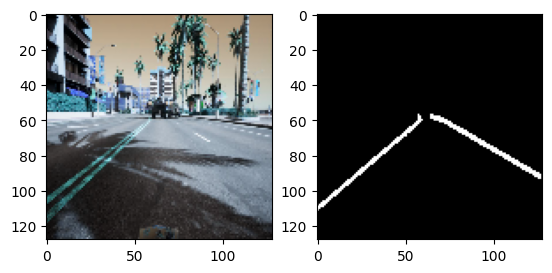

In [153]:
i = random.randint(0, 131075)
print(i)
# i = 66199
image = cv2.imread(f'data/train/images/{i}.png')
mask = cv2.imread(f'data/train/masks/{i}.png')
image = cv2.resize(image, (width, height))
mask = cv2.resize(mask, (width, height)) * 255
print(mask.shape)

plt.subplot(1,2,1)
plt.imshow(image)
plt.subplot(1,2,2)
plt.imshow(mask)

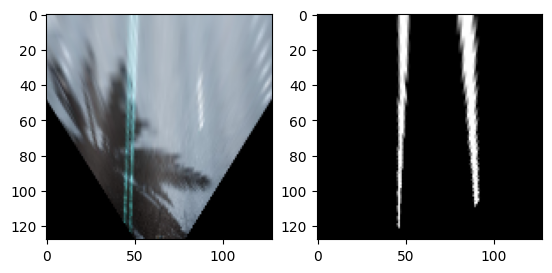

In [154]:
def birdview_transform(img):
    """Apply bird-view transform to the image
    """
    a = 30
    b = 50
    src = np.float32([[0, HEIGHT//2], [WIDTH+0, HEIGHT//2], [0, HEIGHT], [WIDTH, HEIGHT]])
    dst = np.float32([[-a, 0], [WIDTH + a, 0], [b, HEIGHT], [WIDTH-b, HEIGHT]])
    M = cv2.getPerspectiveTransform(src, dst) # The transformation matrix
    warped_img = cv2.warpPerspective(img, M, (WIDTH, HEIGHT)) # Image warping
    return warped_img
plt.subplot(1,2,1)
image_bird = birdview_transform(image)
plt.imshow(image_bird)
plt.subplot(1,2,2)
mask_bird = birdview_transform(mask)
plt.imshow(mask_bird)